<a href="https://colab.research.google.com/github/anfiessi19/CW/blob/main/ML_HW_07_2026_Nasikan_ipynb_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### <center>
### <center>Домашнє завдання №7
##### <center><font color='blue'>Насікан Анни </font>
#### <center>**Кластеризація**

In [13]:
from sklearn.datasets import make_blobs, make_circles, make_moons
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Згенеруйте три набори даних

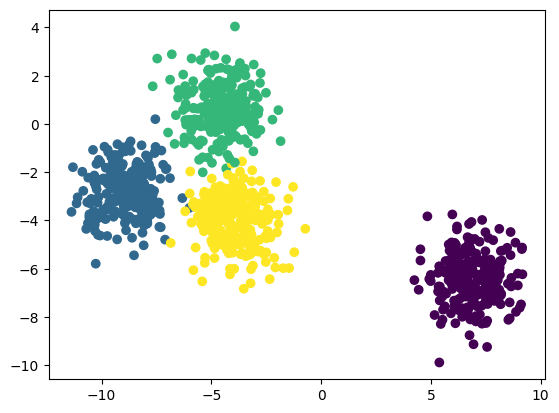

In [14]:
X1, y1 = make_blobs(n_samples=1000, n_features=2, centers=4, random_state=15)
plt.scatter(X1[:,0], X1[:,1], c=y1, cmap='viridis')

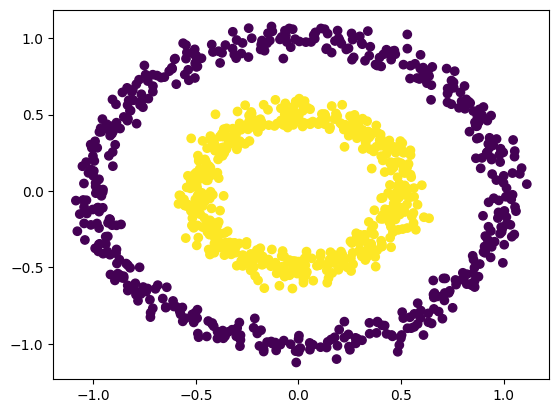

In [15]:
X2, y2 = make_circles(n_samples=1000, noise=.05, factor=.5)
plt.scatter(X2[:,0], X2[:,1], c=y2, cmap='viridis')

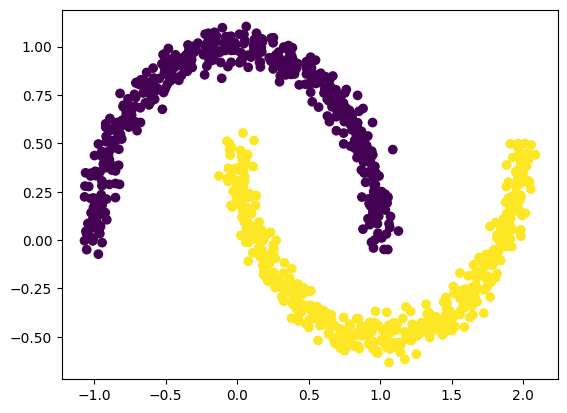

In [16]:
X3, y3 = make_moons(n_samples=1000, noise=.05)
plt.scatter(X3[:,0], X3[:,1], c=y3, cmap='viridis')

**Завдання 1**. Для кожного набору даних виконайте кластеризацію методами KMeans, AgglomerativeClustering, DBSCAN (які розглянуто на парі) та оцініть якість за допомогою метрики силует.

**Завдання 2**. Розглянути методи кластеризації, реалізовану у бібліотеці scikit-learn (https://scikit-learn.org/stable/modules/clustering.html#):
Affinity Propagation, Mean Shift, Spectral clustering,
HDBSCAN, OPTICS, BIRCH та інші.
Застосуйте будь-які два з них до наведених наборів даних і порахуйте метрику силует.

**Завдання 3.** Напишіть висновок, який метод є кращим (найбільш вдалим) на Вашу думку для розв'язання розглянутих задач.

**Силует**

Дана метрика дозволяє оцінити якість кластеризації, використовуючи лише саму (нерозмічену) вибірку та результат кластеризації. Спочатку силует визначається окремо для кожного об'єкта (точки). Позначимо через $a$ - середня відстань від даного об'єкта до об'єктів із того ж кластера, через $b$ - середня відстань від даного об'єкта до об'єктів із найближчого кластера (відмінного від того, в якому лежить сам об'єкт). Тоді силуетом цього об'єкта називається величина: $$s = \frac{b - a}{\max(a, b)}.$$
Силуетом вибірки називається середня величина силуету об'єктів даної вибірки. Таким чином, силует показує, наскільки середня відстань до об'єктів кластера відрізняється від середньої відстані до об'єктів інших кластерів. Ця величина лежить у діапазоні $[-1, 1]$. Значення, близькі до -1, відповідають поганим (розрізненим) кластеризаціям, значення, близькі до нуля, говорять про те, що кластери перетинаються і накладаються один на одного, значення близькі до 1, відповідають "щільним" чітко виділеним кластерам. Таким чином, чим більше силует, тим чіткіше виділені кластери, і вони є компактними, щільно згрупованими хмарами точок.

In [17]:
# @title Текст назви за умовчанням
metrics.silhouette_score(X, labels)

NameError: name 'X' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_circles, make_moons
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering, Birch
from sklearn import metrics

In [ ]:
# Генерація
X1, y1 = make_blobs(n_samples=1000, n_features=2, centers=4, random_state=15)
X2, y2 = make_circles(n_samples=1000, noise=.05, factor=.5)
X3, y3 = make_moons(n_samples=1000, noise=.05)

plt.figure(figsize=(12, 3))
plt.subplot(131); plt.scatter(X1[:,0], X1[:,1], c=y1); plt.title("Blobs")
plt.subplot(132); plt.scatter(X2[:,0], X2[:,1], c=y2); plt.title("Circles")
plt.subplot(133); plt.scatter(X3[:,0], X3[:,1], c=y3); plt.title("Moons")
plt.show()

In [ ]:
methods = {
    "KMeans": lambda n: KMeans(n_clusters=n, n_init=10),
    "Agglomerative": lambda n: AgglomerativeClustering(n_clusters=n),
    "DBSCAN": lambda n: DBSCAN(eps=0.15, min_samples=5),
    "Spectral": lambda n: SpectralClustering(n_clusters=n, affinity='nearest_neighbors'),
    "Birch": lambda n: Birch(n_clusters=n)
}

datasets = [(X1, "Blobs", 4), (X2, "Circles", 2), (X3, "Moons", 2)]

In [ ]:
for X_data, name, n_clusters in datasets:
    print(f"\n--- Результати для {name} ---")
    for m_name, m_func in methods.items():
        try:
            model = m_func(n_clusters)
            labels = model.fit_predict(X_data)
            score = metrics.silhouette_score(X_data, labels)
            print(f"{m_name}: Silhouette Score = {score:.4f}")
        except Exception as e:
            print(f"{m_name}: помилка - {e}")

In [ ]:
#Висновок: Результати підтвердили, що універсального алгоритму для кластеризації не існує.
#KMeans добре працює з простими опуклими групами, але повністю втрачає сенс на складних геометричних формах,
#де значно краще справляються DBSCAN або Spectral Clustering через врахування щільності та зв'язків.
#Метрика силуету показує ці провали у вигляді низьких значень.
#Отже, вибір методу повністю залежить від структури даних